# Scalping Strategy Rules

Develop and test scalping rules.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
# Add project root to path so `src` is importable from the notebook
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parent))

from src.data_collection.load_kaggle_data import load_kaggle_data
from src.preprocessing.clean_data import clean_ohlcv_data
from src.utils.config import DEFAULT_TICKERS

ImportError: cannot import name 'detect_breakout' from 'src.strategy.scalping_logic' (c:\Users\Sunay Bhattacharjee\Desktop\AlgoTrading bot project\SnowMore\algo-trading-project\notebooks\..\src\strategy\scalping_logic.py)

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from src.data_collection.load_kaggle_data import load_kaggle_data
from src.preprocessing.clean_data import clean_ohlcv_data
from src.utils.data_split import split_data_by_date
from src.utils.config import DEFAULT_TICKERS

print("="*70)
print("SCALPING STRATEGY - TECHNICAL RULES BASED APPROACH")
print("="*70)
print("Using: RSI, SMA, Volume analysis")
print("="*70)

Available raw data intervals:
--------------------------------------------------

RELIANCE.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m

TCS.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m

INFY.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m

HDFCBANK.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m

ICICIBANK.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m


## Check Available Data Intervals

In [ ]:
def add_scalping_signals(data):
    """Add scalping signals based on technical rules"""
    df = data.copy()
    
    # RSI
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = -delta.where(delta < 0, 0).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # Moving Averages
    df['SMA_20'] = df['Close'].rolling(20).mean()
    df['SMA_50'] = df['Close'].rolling(50).mean()
    
    # Volume
    df['Volume_SMA'] = df['Volume'].rolling(20).mean()
    
    # Scalping Rules
    # BUY signals:
    # 1. RSI < 30 (Oversold) OR
    # 2. Close > SMA_20 AND SMA_20 > SMA_50 (Uptrend) AND Volume > Average
    buy_signal = (
        (df['RSI'] < 30) |
        ((df['Close'] > df['SMA_20']) & (df['SMA_20'] > df['SMA_50']) & 
         (df['Volume'] > df['Volume_SMA']))
    ).astype(int)
    
    # SELL signals:
    # 1. RSI > 70 (Overbought) OR
    # 2. Close < SMA_20 AND SMA_20 < SMA_50 (Downtrend)
    sell_signal = (
        (df['RSI'] > 70) |
        ((df['Close'] < df['SMA_20']) & (df['SMA_20'] < df['SMA_50']))
    ).astype(int) * -1
    
    # Combine signals: 1 for buy, -1 for sell, 0 for hold
    df['scalp_signal'] = buy_signal + sell_signal
    df['scalp_signal'] = df['scalp_signal'].clip(-1, 1)
    
    return df

# Test on first ticker
ticker = DEFAULT_TICKERS[0]
print(f"\nTesting scalping signals on {ticker}...")

raw_data = load_kaggle_data(ticker)
cleaned = clean_ohlcv_data(raw_data)
train_data, test_data = split_data_by_date(cleaned)

# Get last 100 days of test data for visualization
test_data_signals = add_scalping_signals(test_data.iloc[-100:].copy())

print(f"\nSignal Distribution (Last 100 days of {ticker}):")
print(test_data_signals['scalp_signal'].value_counts().sort_index())

print(f"\nSample signals:")
print(test_data_signals[['Close', 'RSI', 'SMA_20', 'SMA_50', 'scalp_signal']].head(10))

Loaded features from: ..\data\indicators\TCS.NS_features.csv
2025-12-19 18:48:26 - src.strategy.scalping_logic - INFO - Generated scalping signals → 1127 rows
2025-12-19 18:48:26 - src.strategy.scalping_logic - INFO - Detected 143 breakout events
Signals ready — data shape: (1127, 43)


c:\Users\Sunay Bhattacharjee\Desktop\AlgoTrading bot project\SnowMore\algo-trading-project\notebooks\..\src\strategy\scalping_logic.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.   0.   0.   0.   0.   1.5 -1.5 -1.5  0.   0.   1.5  0.   0.   1.5
  0.  -1.5 -1.5 -1.5  0.  -1.5  0.  -1.5 -1.5 -1.5 -1.5  0.   0.  -1.5
 -1.5 -1.5 -1.5 -1.5  0.   0.   0.   0.   0.   0.  -1.5  0.   0.   0.
  1.5 -1.5 -1.5 -1.5  0.  -1.5  0.   0.   0.   0.   0.   0.   0.  -1.5
  0.   0.   0.   0.   1.5  0.   0.   1.5  1.5  0.   0.  -1.5  0.   0.
  0.   0.   0.  -1.5  0.   0.   0.   0.   0.   0.  -1.5  1.5  0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.  -1.5  0.   0.  -1.5 -1.5  1.5
 -1.5  0.   0.   0.   0.   0.  -1.5  0.   0.   0.  -1.5  0.   0.   0.
 -1.5  0.   0.   0.   0.   1.5  0.   0.   0.   0.   0.   0.   0.   0.
  0.   1.5  0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype 

,Close,scalp_signal,breakout_signal
Price,,,
2024-10-29,3938.259766,0.0,0
2024-10-30,3947.343994,0.0,0
2024-10-31,3835.050049,0.0,-1
2024-11-01,3850.270752,0.0,0
2024-11-04,3830.894775,0.0,0
2024-11-05,3837.852539,0.0,0
2024-11-06,4000.494873,0.0,0
2024-11-07,4011.366943,1.0,0
2024-11-08,4007.597900,0.0,0


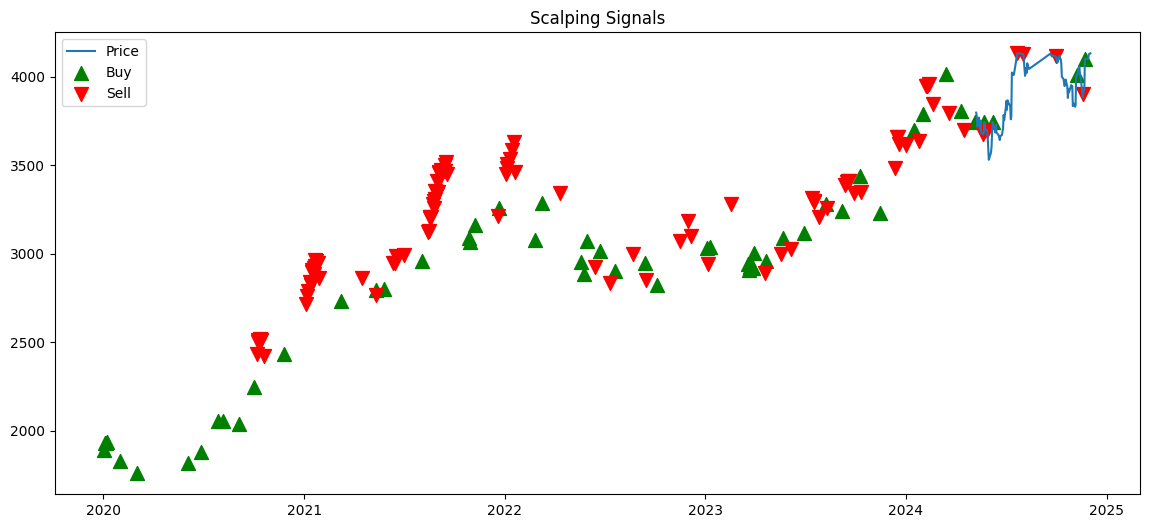

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Price with Moving Averages and Signals
ax = axes[0]
ax.plot(test_data_signals.index, test_data_signals['Close'], label='Close', linewidth=2)
ax.plot(test_data_signals.index, test_data_signals['SMA_20'], label='SMA 20', alpha=0.7)
ax.plot(test_data_signals.index, test_data_signals['SMA_50'], label='SMA 50', alpha=0.7)

# Mark buy and sell signals
buy_signals = test_data_signals[test_data_signals['scalp_signal'] == 1]
sell_signals = test_data_signals[test_data_signals['scalp_signal'] == -1]

ax.scatter(buy_signals.index, buy_signals['Close'], color='green', marker='^', s=100, label='Buy Signal', zorder=5)
ax.scatter(sell_signals.index, sell_signals['Close'], color='red', marker='v', s=100, label='Sell Signal', zorder=5)

ax.set_title(f'Scalping Signals - {ticker}')
ax.set_ylabel('Price')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: RSI
ax = axes[1]
ax.plot(test_data_signals.index, test_data_signals['RSI'], label='RSI', linewidth=2)
ax.axhline(y=30, color='g', linestyle='--', alpha=0.5, label='Oversold (30)')
ax.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Overbought (70)')
ax.fill_between(test_data_signals.index, 30, 70, alpha=0.1, color='gray')
ax.set_title('RSI Signal')
ax.set_ylabel('RSI')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Volume
ax = axes[2]
ax.bar(test_data_signals.index, test_data_signals['Volume'], width=0.01, alpha=0.5, label='Volume')
ax.plot(test_data_signals.index, test_data_signals['Volume_SMA'], color='red', linewidth=2, label='Volume SMA')
ax.set_title('Volume Analysis')
ax.set_ylabel('Volume')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()